# Osteoporosis Risk EDA

This notebook profiles missingness, class balance, numeric relationships, and distributions before model training. A measured BMD T-score is treated as a clinical label source, not as a fabricated value.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import RAW_CSV
from src.data_generator import generate_dataset

sns.set_theme(style="whitegrid")
df = pd.read_csv(RAW_CSV) if Path(RAW_CSV).exists() else generate_dataset(save=False)
df.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,BMD_T_Score,Risk_Label,Osteoporosis
0,68,Female,Normal,No,Caucasian,31.2,Low,Sufficient,Active,Yes,None,None,Anticonvulsants,No,-1.17,Osteopenia,0
1,81,Female,Normal,Yes,African American,31.9,Adequate,Deficient,Sedentary,No,High,None,Anticonvulsants,No,-2.82,Osteoporosis,1
2,58,Female,Postmenopausal,No,Hispanic,26.2,Adequate,Sufficient,Active,No,High,None,Anticonvulsants,No,-1.41,Osteopenia,0
3,44,Female,Normal,No,Caucasian,32.6,Adequate,Deficient,Active,Yes,None,None,None,Yes,-1.31,Osteopenia,0
4,72,Male,Postmenopausal,No,African American,27.0,Adequate,Sufficient,Sedentary,No,None,None,Antidepressants,Yes,-1.76,Osteopenia,0


## Data quality and class balance

,missing_percent
Age,0.0
Gender,0.0
Hormonal Changes,0.0
Family History,0.0
Race/Ethnicity,0.0
Body Weight,0.0
Calcium Intake,0.0
Vitamin D Intake,0.0
Physical Activity,0.0
Smoking,0.0


,count
Risk_Label,
Osteopenia,1333
Osteoporosis,360
Normal,307


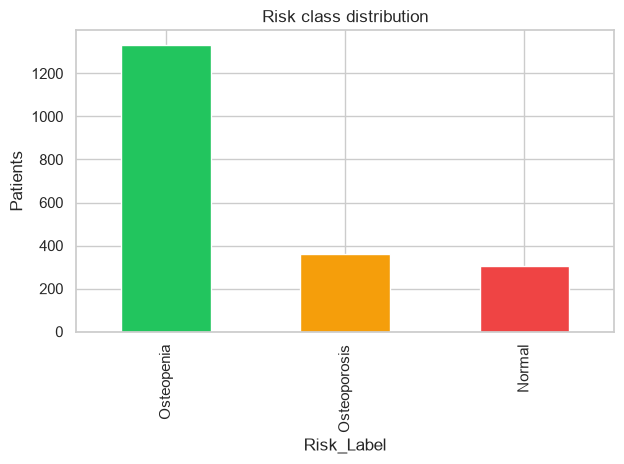

In [2]:
missing = (df.isna().mean().sort_values(ascending=False) * 100).rename("missing_percent")
display(missing.to_frame())

target = "Risk_Label" if "Risk_Label" in df else "risk_label"
class_counts = df[target].value_counts(dropna=False)
display(class_counts.to_frame("count"))
class_counts.plot(kind="bar", title="Risk class distribution", color=["#22c55e", "#f59e0b", "#ef4444"])
plt.ylabel("Patients")
plt.tight_layout()

## Numeric relationships

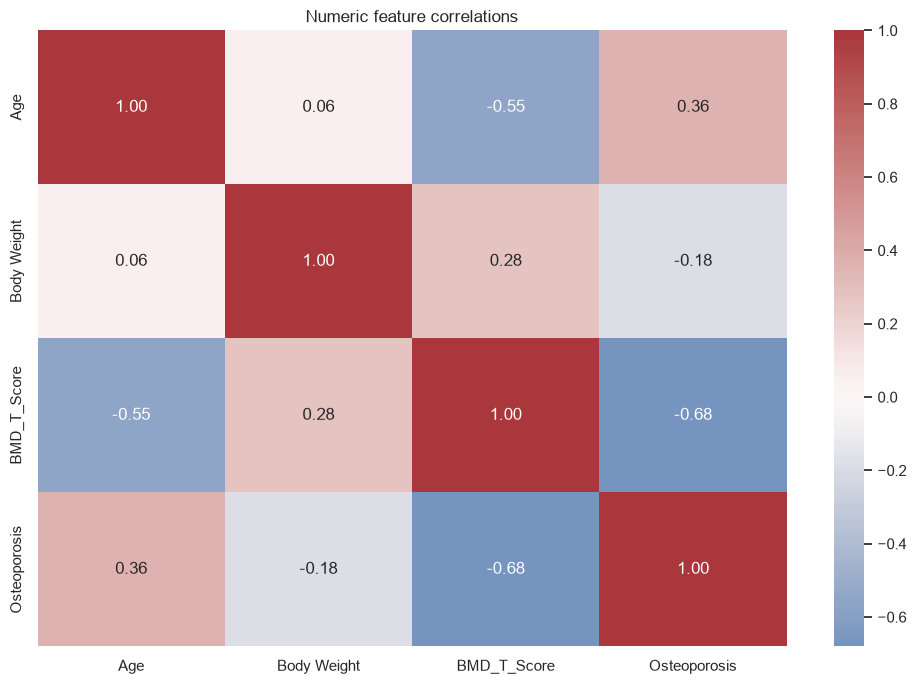

In [3]:
numeric = df.select_dtypes(include="number")
plt.figure(figsize=(10, 7))
sns.heatmap(numeric.corr(), cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Numeric feature correlations")
plt.tight_layout()

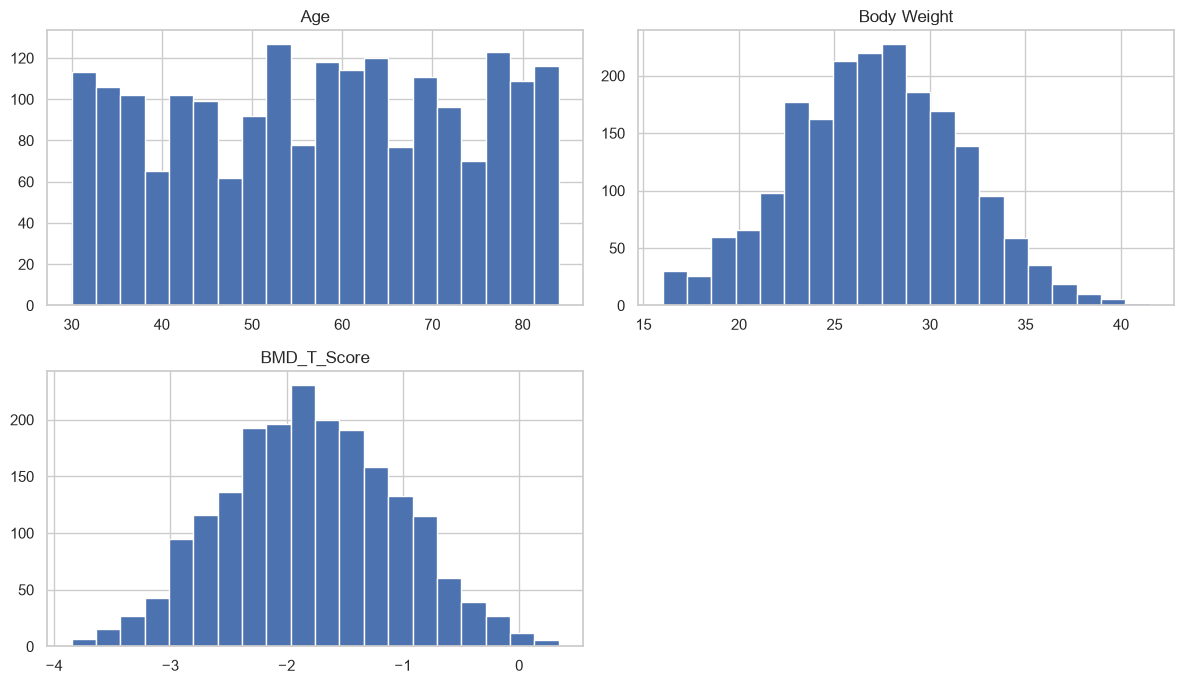

In [4]:
plot_columns = [column for column in ["Age", "BMI", "Body Weight", "BMD_T_Score"] if column in df.columns]
if plot_columns:
    df[plot_columns].hist(figsize=(12, 7), bins=20)
    plt.tight_layout()